#SVM: Support vector machine
it is a supervised learning. it is also used for regression and classification:
whatever regression algorithams are there you can use for classification also:  
it is a concept  of finding a hyperplane that best separates the data into different classes.  
works well with both linear and non linear classification problems  
robust to overfitting especially in high dimesnional feature spaces

viva question: assumptions of linear regression

we used : SLR,MLR,Overfitting(regularisation(lasso,ridge,elasticnet))
from these assumptions were
1. x fetaures and y target variable should have strong relationship
2. Ho moscedasticity(variance should be constant)
3. no multicolinearity(x and x we dont want no relationship)
4. residuak akso follow normal distribution

plot Normal distribution is histogram. scatterplot for relation between variable. box plot is useed to find outliers

linear data means strong relationship between x and y  
SVM works on 4 main imp points  
1. hyperplane: when there is a 2d data and you convert it to 3d. like passing a line between two class of data is plane. same thing in 3d. gives max margine btw the class. we  need to get an hyper plane which separates two classes perfectly.  
2. maximum margin  between 2 hyperplane
3. support vectors   
4. kernel(linear, polynomial and rbf)  


when the data is linearly separable svm finds the hyperplane that maximizes the
logiostic regression  works well on binary target variable
svm works on non linear data and gives best performance


non linear data and classification problem then go with SVM


SUPPORT VECTOR MACHINE  
Dataset Selection:  
Data set Description described in another document “Drug Response Classification”  
Task 1: Exploratory Data Analysis (EDA)  
1.	Load the dataset and perform fundamental data exploration.  
2.	Utilize histograms, box plots, or density plots to understand feature distributions.  
3.	Investigate feature correlations to discern relationships within the data.  
Task 2: Data Preprocessing    
1.	Encode categorical variables if necessary.  
2.	Split the dataset into training and testing sets.  
Task 3: Data Visualization    
1.	Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.  
2.	Visualize class distributions to gauge dataset balance or imbalance.
Task 4: SVM Implementation  
1.	Implement a basic SVM classifier using Python libraries like scikit-learn.
2.	Train the SVM model on the training data.  
3.	Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).  
Task 5: Visualization of SVM Results  
1.	Visualize classification results on the testing data.  
Task 6: Parameter Tuning and Optimization  
1.	Experiment with different SVM hyperparameters (e.g., kernel type,   regularization parameter) to optimize performance.  
Task 7: Comparison and Analysis  
1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).  
2.	Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.  
3.	Discuss practical implications of SVM in real-world classification tasks.  



Business Context
Pharmaceutical companies invest millions of dollars in clinical trials to test drug efficacy. However, some drugs do not work for all patients due to individual differences in biology, metabolism, and pre-existing conditions.
Traditional clinical trials take years to conclude, with high costs and risks.
Machine learning models can help predict drug response early, saving time and resources.  
Personalized medicine ensures that patients receive the right drug at the right dose.   
-------------------------------------------------------------------------------------------------------------------------------  
Drug Response Classification (0 = No response, 1 = Positive response)
Drug response classification refers to how a patient’s body reacts to a particular drug. This is a key concept in pharmaceutical research and clinical trials, where researchers analyze whether a drug is effective or not based on biological responses.  
Interpretation of Classification Labels:  
1.	0 = No Response  
o	The drug did not have a significant effect on the patient.  
o	The patient’s condition remained unchanged after taking the drug.  
o	The biomarkers (e.g., blood pressure, glucose level, heart rate) did not improve.  
o	Possible reasons:  
	The drug is not suitable for the patient.  
	The dosage is ineffective.  
	The patient's metabolism is resistant to the drug.  
2.	1 = Positive Response  
o	The drug had a beneficial effect on the patient.  
o	The patient’s condition improved after taking the drug.  
o	Biomarkers such as blood pressure, glucose levels, and enzyme activity show significant improvement.  
o	Possible reasons:  
	The drug is effective for this patient.  
	The dosage is appropriate.  
	The patient’s metabolism responds well to the drug.  



Why is This Classification Important?
•	Pharmaceutical Industry: Used to test new drugs and evaluate their effectiveness before FDA approval.
•	Personalized Medicine: Helps doctors prescribe drugs based on individual patient responses.
•	Machine Learning in Healthcare: Enables predictive models to forecast patient responses based on medical data.





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
df=pd.read_csv('/content/Pharma_Industry.csv')
df

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1
...,...,...,...,...,...,...
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0


In [ ]:
df.isnull().sum()

,0
Drug Dosage (mg),0
Systolic Blood Pressure (mmHg),0
Heart Rate (BPM),0
Liver Toxicity Index (U/L),0
Blood Glucose Level (mg/dL),0
Drug Response,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(500, 6)

In [ ]:
df.size

3000

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [ ]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [ ]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [ ]:
df.tail()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0
499,-1.143726,0.715320,0.108560,-0.509787,-0.250704,1


In [ ]:
y= df['Drug Response']
x= df.iloc[:,0:3]
x.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM)
0,-0.128538,0.303280,-1.881849
1,-1.846188,2.865142,-0.929511
2,-1.252393,-1.541613,0.363632
3,1.992515,-1.142779,-0.766657
4,0.377100,0.538410,-0.029263


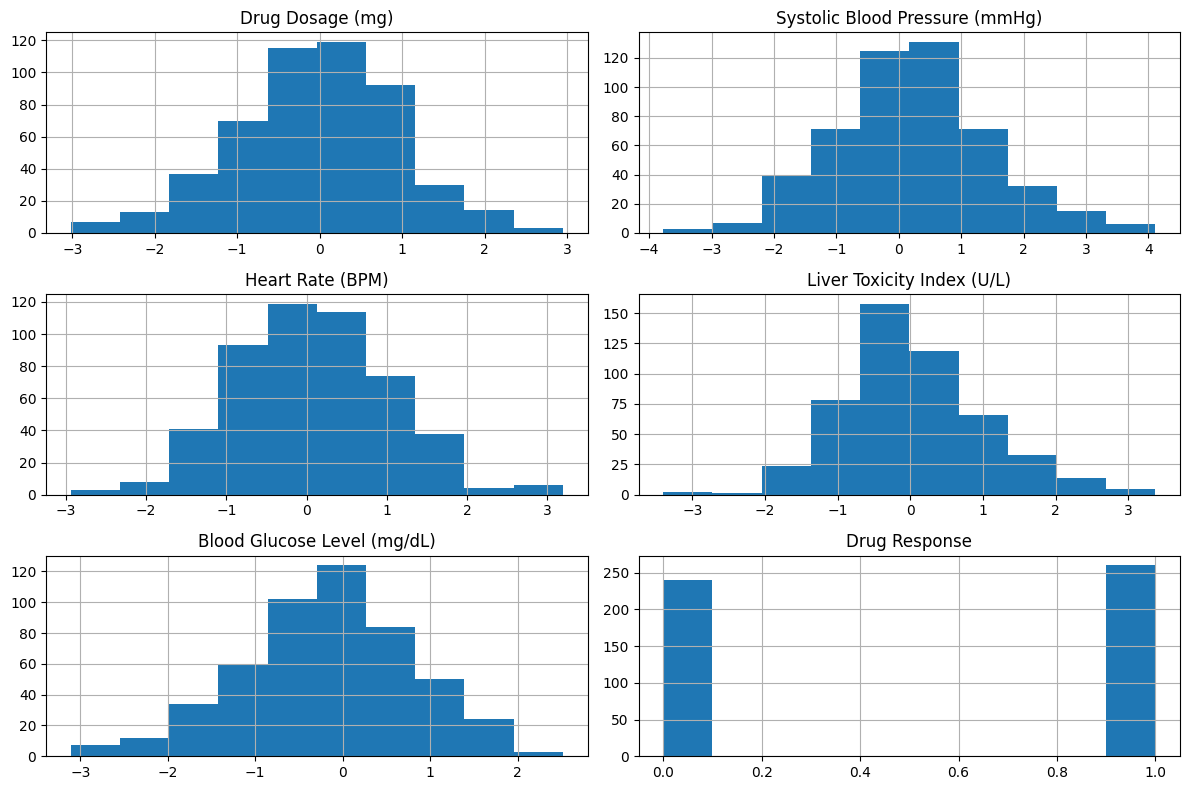

In [ ]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

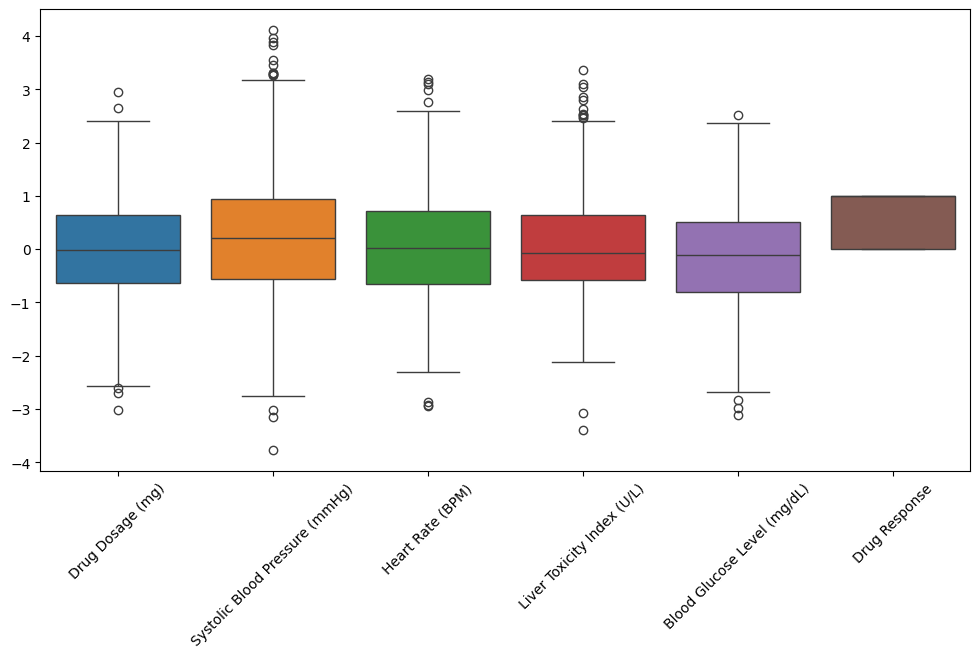

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.show()

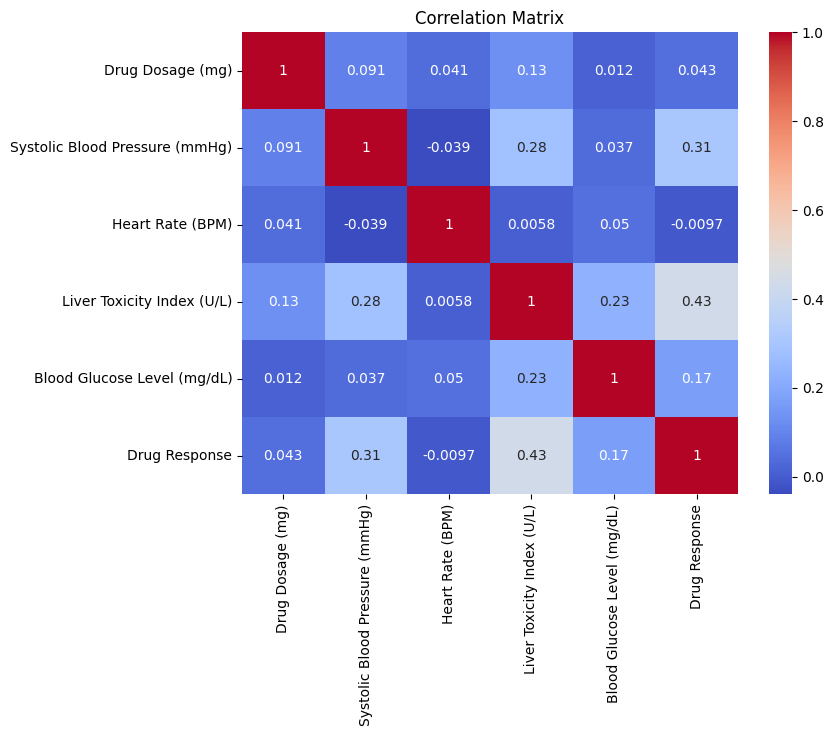

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

In [ ]:
X

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355
4,0.377100,0.538410,-0.029263,1.896015,-0.960130
...,...,...,...,...,...
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393
496,0.551476,1.714321,0.340589,1.712558,-0.496315
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838
498,1.661259,0.245759,-0.457096,0.633355,0.657413


In [ ]:
y

,Drug Response
0,1
1,1
2,0
3,1
4,1
...,...
495,0
496,1
497,1
498,0


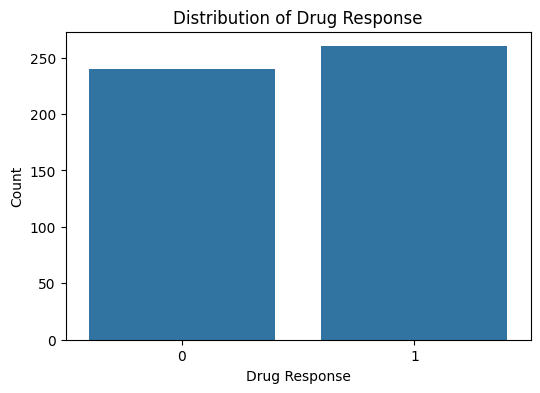

Drug Response
1    260
0    240
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Drug Response', data=df)
plt.title("Distribution of Drug Response")
plt.xlabel("Drug Response")
plt.ylabel("Count")
plt.show()

print(df['Drug Response'].value_counts())
#Drug Response was visualized to determine whether the dataset is balanced.

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test  = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}

In [ ]:
grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.1, 0.01],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']},
             scoring='accuracy')

# Hyperparameter Tuning using GridSearchCV
GridSearchCV was used to identify the best combination of hyperparameters for the SVM model using 5-fold cross-validation. This helps improve model performance and reduces the risk of selecting suboptimal parameter values.

In [ ]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Score:")
print(grid.best_score_)
#GridSearchCV was used with 5-fold cross-validation to identify the best combination of kernel, C, and gamma values. The tuned model was then used for prediction to improve overall performance.


In [ ]:
best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)

In [ ]:
#define svm models with different kernels
svm_linear= SVC(kernel='linear', C=1.0)
svm_poly = SVC(kernel='poly', degree=3, C=1.0)
svm_rbf = SVC(kernel='rbf', gamma=0.1, C=1.0)

In [ ]:
#Train and evaluate SVM with linear kernel
svm_linear.fit(x_train, y_train)
y_pred_linear = svm_linear.predict(x_test)
accuracy_linear = accuracy_score(y_test, y_pred_linear)

In [ ]:
#Train and evaluate SVM with polynomial kernel
svm_poly.fit(x_train, y_train)
y_pred_poly = svm_poly.predict(x_test)
accuracy_poly = accuracy_score(y_test, y_pred_poly)

In [ ]:
#Train and evaluate SVM with rbf kernel
svm_rbf.fit(x_train, y_train)
y_pred_rbf = svm_rbf.predict(x_test)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
# Define and evaluate SVM with sigmoid kernel
svm_sigmoid = SVC(kernel='sigmoid', gamma=0.1, C=1.0)
svm_sigmoid.fit(x_train, y_train)
y_pred_sigmoid = svm_sigmoid.predict(x_test)
accuracy_sigmoid = accuracy_score(y_test, y_pred_sigmoid)


Classification Report
              precision    recall  f1-score   support

           0       0.54      0.65      0.59        69
           1       0.64      0.53      0.58        81

    accuracy                           0.59       150
   macro avg       0.59      0.59      0.59       150
weighted avg       0.60      0.59      0.59       150



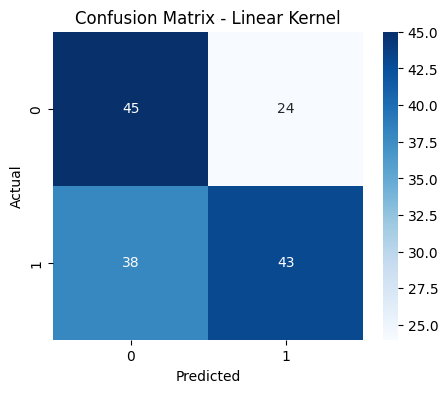

              precision    recall  f1-score   support

           0       0.55      0.78      0.64        69
           1       0.71      0.44      0.55        81

    accuracy                           0.60       150
   macro avg       0.63      0.61      0.59       150
weighted avg       0.63      0.60      0.59       150



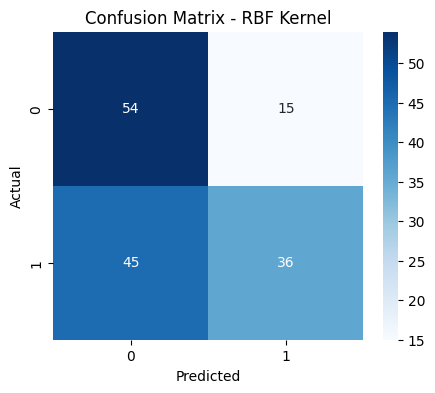

              precision    recall  f1-score   support

           0       0.53      0.87      0.66        69
           1       0.75      0.33      0.46        81

    accuracy                           0.58       150
   macro avg       0.64      0.60      0.56       150
weighted avg       0.65      0.58      0.55       150



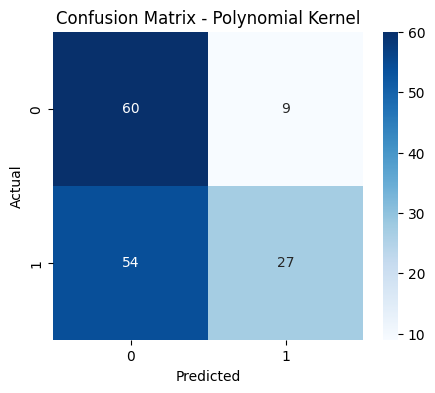

              precision    recall  f1-score   support

           0       0.55      0.70      0.62        69
           1       0.67      0.52      0.58        81

    accuracy                           0.60       150
   macro avg       0.61      0.61      0.60       150
weighted avg       0.61      0.60      0.60       150



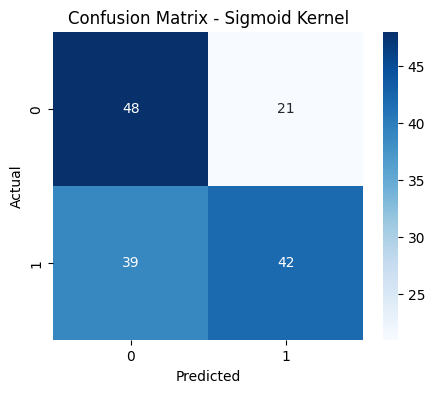

In [ ]:
# Calculate precision, recall, and F1-score for all kernels

# Linear Kernel
precision_linear = precision_score(y_test, y_pred_linear, average='weighted')
recall_linear = recall_score(y_test, y_pred_linear, average='weighted')
f1_linear = f1_score(y_test, y_pred_linear, average='weighted')

from sklearn.metrics import classification_report

print("\nClassification Report")
print(classification_report(y_test, y_pred_linear))

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_linear)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Linear Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# RBF Kernel
precision_rbf = precision_score(y_test, y_pred_rbf, average='weighted')
recall_rbf = recall_score(y_test, y_pred_rbf, average='weighted')
f1_rbf = f1_score(y_test, y_pred_rbf, average='weighted')

print(classification_report(y_test, y_pred_rbf))

cm = confusion_matrix(y_test, y_pred_rbf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - RBF Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Polynomial Kernel
precision_poly = precision_score(y_test, y_pred_poly, average='weighted')
recall_poly = recall_score(y_test, y_pred_poly, average='weighted')
f1_poly = f1_score(y_test, y_pred_poly, average='weighted')

print(classification_report(y_test, y_pred_poly))

cm = confusion_matrix(y_test, y_pred_poly)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Polynomial Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Sigmoid Kernel
precision_sigmoid = precision_score(y_test, y_pred_sigmoid, average='weighted')
recall_sigmoid = recall_score(y_test, y_pred_sigmoid, average='weighted')
f1_sigmoid = f1_score(y_test, y_pred_sigmoid, average='weighted')

print(classification_report(y_test, y_pred_sigmoid))

cm = confusion_matrix(y_test, y_pred_sigmoid)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Sigmoid Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(f"Linear Accuracy: {accuracy_linear:.2f}, Precision: {precision_linear:.2f}, Recall: {recall_linear:.2f}, F1: {f1_linear:.2f}")
print(f"RBF Accuracy: {accuracy_rbf:.2f}, Precision: {precision_rbf:.2f}, Recall: {recall_rbf:.2f}, F1: {f1_rbf:.2f}")
print(f"Polynomial Accuracy: {accuracy_poly:.2f}, Precision: {precision_poly:.2f}, Recall: {recall_poly:.2f}, F1: {f1_poly:.2f}")
print(f"Sigmoid Accuracy: {accuracy_sigmoid:.2f}, Precision: {precision_sigmoid:.2f}, Recall: {recall_sigmoid:.2f}, F1: {f1_sigmoid:.2f}")

Linear Accuracy: 0.59, Precision: 0.60, Recall: 0.59, F1: 0.59
RBF Accuracy: 0.60, Precision: 0.63, Recall: 0.60, F1: 0.59
Polynomial Accuracy: 0.58, Precision: 0.65, Recall: 0.58, F1: 0.55
Sigmoid Accuracy: 0.60, Precision: 0.61, Recall: 0.60, F1: 0.60


In [ ]:

results = pd.DataFrame({
    "Kernel": ["Linear","RBF","Polynomial","Sigmoid"],
    "Accuracy": [
        accuracy_linear,
        accuracy_rbf,
        accuracy_poly,
        accuracy_sigmoid
    ],
    "Precision":[
        precision_linear,
        precision_rbf,
        precision_poly,
        precision_sigmoid
    ],
    "Recall":[
        recall_linear,
        recall_rbf,
        recall_poly,
        recall_sigmoid
    ],
    "F1 Score":[
        f1_linear,
        f1_rbf,
        f1_poly,
        f1_sigmoid
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Kernel,Accuracy,Precision,Recall,F1 Score
1,RBF,0.600000,0.632086,0.600000,0.590260
3,Sigmoid,0.600000,0.613793,0.600000,0.598077
0,Linear,0.586667,0.595965,0.586667,0.586152
2,Polynomial,0.580000,0.647105,0.580000,0.550870


#we take linear model for best fit

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


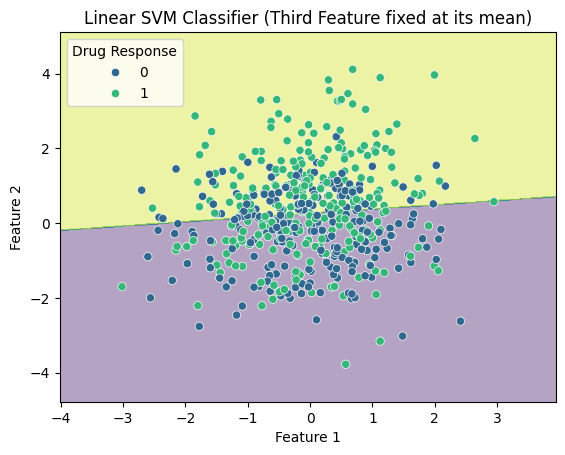

In [ ]:
# prompt: visualize the data for the above linear classifer

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap

# Assuming x and y are defined as in your previous code.
# x_train, x_test, y_train, y_test, svm_linear are also assumed to be defined.

# Create a meshgrid to visualize the decision boundary
x_min, x_max = x.iloc[:, 0].min() - 1, x.iloc[:, 0].max() + 1
y_min, y_max = x.iloc[:, 1].min() - 1, x.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Calculate the mean of the third feature to fix it for 2D visualization
third_feature_mean = x.iloc[:, 2].mean()

# Predict the class for each point in the meshgrid using svm_linear
# Include the mean of the third feature for the prediction
X_mesh = np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, third_feature_mean)]
Z = svm_linear.predict(X_mesh)
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the data points
plt.contourf(xx, yy, Z, alpha=0.4)
sns.scatterplot(x=x.iloc[:, 0], y=x.iloc[:, 1], hue=y, palette="viridis")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linear SVM Classifier (Third Feature fixed at its mean)")
plt.show()


In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Polynomial classifier
model = SVC(kernel='poly', degree=3)   # degree = 2,3,4
model.fit(x_train,y_train)
Y_pred_train = model.predict(x_train)
Y_pred_test = model.predict(x_test)


score1 = accuracy_score(y_train,Y_pred_train)
score2 = accuracy_score(y_test,Y_pred_test)

print("Training score:", np.round(score1, 2))
print("Test score:", np.round(score2, 2))

Training score: 0.62
Test score: 0.58


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


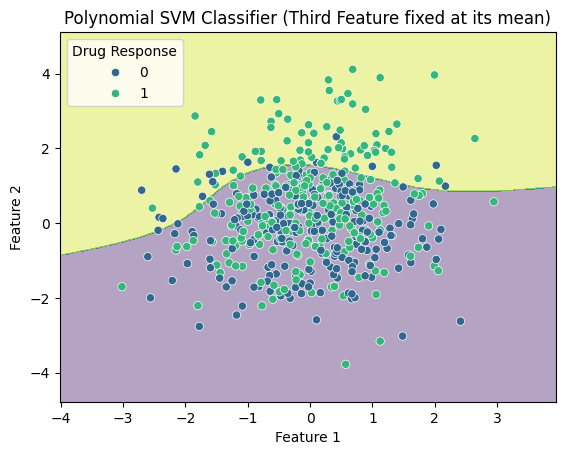

In [ ]:
# prompt: visualize the data for the above linear classifer

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy
from matplotlib.colors import ListedColormap

# Assuming x and y are defined as in your previous code.
# x_train, x_test, y_train, y_test, model are also assumed to be defined.

# Create a meshgrid to visualize the decision boundary
# Use 'x' which contains the 3 features that the model was trained on
x_min, x_max = x.iloc[:, 0].min() - 1, x.iloc[:, 0].max() + 1
y_min, y_max = x.iloc[:, 1].min() - 1, x.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Calculate the mean of the third feature (index 2) from 'x' to fix it for 2D visualization
third_feature_mean = x.iloc[:, 2].mean()

# Predict the class for each point in the meshgrid by concatenating the third feature
X_mesh = np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, third_feature_mean)]
Z = model.predict(X_mesh)
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the data points
plt.contourf(xx, yy, Z, alpha=0.4)
sns.scatterplot(x=x.iloc[:, 0], y=x.iloc[:, 1], hue=y, palette="viridis")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Polynomial SVM Classifier (Third Feature fixed at its mean)") # Updated title
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


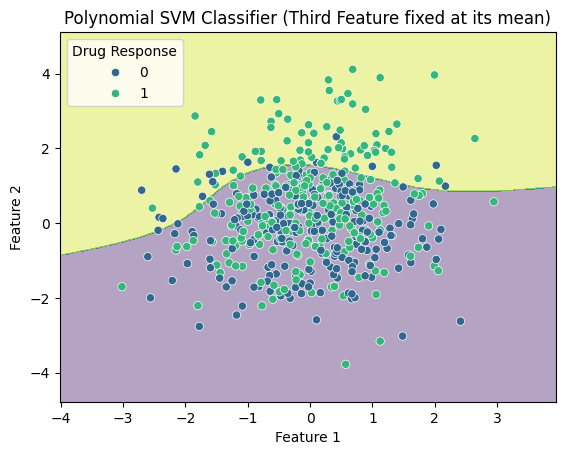

In [ ]:
# prompt: visualize the data for the above linear classifer

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy
from matplotlib.colors import ListedColormap

# Assuming x and y are defined as in your previous code.
# x_train, x_test, y_train, y_test, model are also assumed to be defined.

# Create a meshgrid to visualize the decision boundary
# Use 'x' which contains the 3 features that the model was trained on
x_min, x_max = x.iloc[:, 0].min() - 1, x.iloc[:, 0].max() + 1
y_min, y_max = x.iloc[:, 1].min() - 1, x.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Calculate the mean of the third feature (index 2) from 'x' to fix it for 2D visualization
third_feature_mean = x.iloc[:, 2].mean()

# Predict the class for each point in the meshgrid by concatenating the third feature
X_mesh = np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, third_feature_mean)]
Z = model.predict(X_mesh)
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the data points
plt.contourf(xx, yy, Z, alpha=0.4)
sns.scatterplot(x=x.iloc[:, 0], y=x.iloc[:, 1], hue=y, palette="viridis")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Polynomial SVM Classifier (Third Feature fixed at its mean)") # Updated title
plt.show()

In this assignment, four SVM kernels (Linear, RBF, Polynomial, and Sigmoid) were tested to predict the drug response. The models were compared using Accuracy, Precision, Recall, and F1-score.

The Linear kernel gave good results and was simple to train. It works well when the data can be separated with a straight line, but it may not perform well if the relationship between the features is more complex.

The RBF kernel handled nonlinear data better and generally gave better overall performance.

The Polynomial kernel was also able to classify nonlinear data, but it required more computation and could overfit if the degree was too high.

The Sigmoid kernel showed the least consistent performance among the four kernels.

GridSearchCV helped improve the model by selecting the best hyperparameters.

Overall, the kernel with the highest Accuracy and F1-score was selected as the best model.


#Conclusion:
In this assignment, Support Vector Machine (SVM) was used to classify drug response using different kernel functions. The performance of each model was evaluated using Accuracy, Precision, Recall, F1-score, and the confusion matrix instead of relying only on accuracy. GridSearchCV was also applied to find the best hyperparameter values and improve the model's performance.

After comparing all the kernels, the model with the highest Accuracy and F1-score was considered the best choice for predicting drug response. Overall, this assignment showed that SVM is an effective machine learning algorithm for drug response classification when the appropriate kernel and parameters are selected.
